In [13]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from pathlib import Path

# =========================================================
# 1. CONFIGURATION
# =========================================================

base_path = Path("/Users/karlavega/Documents/GitHub/Forest_Peru/Scrapping/data")

files = {
    2006: "distrital_2006.csv",
    2010: "distrital_2010.csv",
    2014: "distrital_2014.csv",
    2018: "distrital_2018.csv",
    2022: "distrital_2022.csv",
}

output_dir = Path(".")
output_dir.mkdir(exist_ok=True)



In [14]:
# =========================================================
# 2. HELPERS
# =========================================================

def read_csv_safe(path_file):
    try:
        df = pd.read_csv(path_file)
    except UnicodeDecodeError:
        df = pd.read_csv(path_file, encoding="latin1")
    return df


def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""


def format_cell(model, varname, decimals=4):
    if varname not in model.params.index:
        return ""
    coef = model.params[varname]
    se = model.bse[varname]
    pval = model.pvalues[varname]
    return f"{coef:.{decimals}f}{stars(pval)} ({se:.{decimals}f})"


def get_cluster_count(df, cluster_var="ubigeo"):
    return df[cluster_var].nunique()


def fit_ols_cluster(formula, data, cluster_var="ubigeo"):
    model = smf.ols(formula=formula, data=data).fit(
        cov_type="cluster",
        cov_kwds={"groups": data[cluster_var]}
    )
    return model


def write_latex_table(
    models,
    column_labels,
    row_order,
    row_labels,
    fe_rows,
    depvar_mean,
    n_obs,
    n_clusters,
    caption,
    label,
    file_path,
    notes=None
):
    lines = []
    lines.append("\\begin{table}[htbp]")
    lines.append("\\centering")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append("\\begin{tabular}{l" + "c" * len(models) + "}")
    lines.append("\\toprule")
    lines.append(" & " + " & ".join(column_labels) + " \\\\")
    lines.append("\\midrule")

    for var in row_order:
        row_name = row_labels.get(var, var)
        vals = [format_cell(m, var) for m in models]
        lines.append(f"{row_name} & " + " & ".join(vals) + " \\\\")

    lines.append("\\midrule")

    for row_name, values in fe_rows.items():
        lines.append(f"{row_name} & " + " & ".join(values) + " \\\\")

    lines.append(f"Mean dep. var. & " + " & ".join([f"{depvar_mean:.4f}"] * len(models)) + " \\\\")
    lines.append(f"Observations & " + " & ".join([str(n_obs)] * len(models)) + " \\\\")
    lines.append(f"Clusters & " + " & ".join([str(n_clusters)] * len(models)) + " \\\\")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")

    if notes is None:
        notes = "Robust standard errors clustered at the district level in parentheses. * $p<0.10$, ** $p<0.05$, *** $p<0.01$."

    lines.append("\\begin{flushleft}")
    lines.append("\\footnotesize " + notes)
    lines.append("\\end{flushleft}")
    lines.append("\\end{table}")

    latex_str = "\n".join(lines)

    with open(file_path, "w", encoding="utf-8") as f:
        f.write(latex_str)

    return latex_str




In [15]:
# =========================================================
# 3. LOAD AND STACK DATA
# =========================================================

dfs = []

for year, filename in files.items():
    df_tmp = read_csv_safe(base_path / filename)
    df_tmp.columns = df_tmp.columns.str.strip().str.lower()
    df_tmp["year"] = year
    df_tmp["original_file_order"] = np.arange(1, len(df_tmp) + 1)
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

# =========================================================
# 4. BASIC CLEANING
# =========================================================

text_cols = ["region", "provincia", "distrito", "organizacion_politica"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df["ubigeo"] = pd.to_numeric(df["ubigeo"], errors="coerce")
df["total_votos"] = pd.to_numeric(df["total_votos"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

df = df.dropna(subset=["ubigeo", "organizacion_politica", "year", "total_votos"]).copy()

# =========================================================
# 5. CONSTRUCT POSITION FROM ORIGINAL ORDER WITHIN DISTRICT-YEAR
# =========================================================

df = df.sort_values(["year", "ubigeo", "original_file_order"]).copy()

df["position"] = (
    df.groupby(["year", "ubigeo"], sort=False)
      .cumcount() + 1
)

# =========================================================
# 6. DEPENDENT VARIABLE: WIN
# =========================================================

max_votes = df.groupby(["year", "ubigeo"])["total_votos"].transform("max")
df["win"] = (df["total_votos"] == max_votes).astype(int)

# =========================================================
# 7. MOVEMENT / PARTY INDICATOR
# =========================================================

org_upper = df["organizacion_politica"].str.upper()

df["movement"] = org_upper.str.contains("MOVIMIENTO", na=False).astype(int)
df["org_type"] = np.where(df["movement"] == 1, "Movement", "Party")

# position squared
df["position_sq"] = df["position"] ** 2

# =========================================================
# 8. SAMPLE RESTRICTIONS
# =========================================================

df = df[df["position"] <= 15].copy()

df["n_pos_year"] = df.groupby(["year", "position"])["position"].transform("size")
df = df[df["n_pos_year"] >= 30].copy()



In [16]:
# =========================================================
# 9. SUMMARY STATS FOR TABLE FOOTERS
# =========================================================

depvar_mean = df["win"].mean()
n_obs = len(df)
n_clusters = get_cluster_count(df, "ubigeo")

print("Final sample size:", n_obs)
print("Dependent variable mean:", round(depvar_mean, 4))
print("Number of clusters:", n_clusters)



Final sample size: 51862
Dependent variable mean: 0.1667
Number of clusters: 1693


In [17]:
# =========================================================
# 10. MODEL SETS
# =========================================================
# Requested columns:
# (1) No FE
# (2) District FE
# (3) District FE + Election year FE
# (4) District FE + Election year FE + org type control

# -------------------------------
# TABLE 1: No interaction
# -------------------------------
m1_1 = fit_ols_cluster("win ~ position", df)
m1_2 = fit_ols_cluster("win ~ position + C(ubigeo)", df)
m1_3 = fit_ols_cluster("win ~ position + C(ubigeo) + C(year)", df)
m1_4 = fit_ols_cluster("win ~ position + movement + C(ubigeo) + C(year)", df)

models_table1 = [m1_1, m1_2, m1_3, m1_4]

# -------------------------------
# TABLE 2: Interaction with movement
# -------------------------------
m2_1 = fit_ols_cluster("win ~ position + movement + position:movement", df)
m2_2 = fit_ols_cluster("win ~ position + movement + position:movement + C(ubigeo)", df)
m2_3 = fit_ols_cluster("win ~ position + movement + position:movement + C(ubigeo) + C(year)", df)

models_table2 = [m2_1, m2_2, m2_3]

# -------------------------------
# TABLE 3: Interaction with movement, position, and position squared
# -------------------------------
m3_1 = fit_ols_cluster(
    "win ~ position + position_sq + movement + position:movement + position_sq:movement",
    df
)
m3_2 = fit_ols_cluster(
    "win ~ position + position_sq + movement + position:movement + position_sq:movement + C(ubigeo)",
    df
)
m3_3 = fit_ols_cluster(
    "win ~ position + position_sq + movement + position:movement + position_sq:movement + C(ubigeo) + C(year)",
    df
)


models_table3 = [m3_1, m3_2, m3_3]



In [18]:
print("\n" + "="*80)
print("TABLE 1 MODELS (NO INTERACTION)")
print("="*80)

for i, m in enumerate(models_table1, 1):
    print(f"\n--- Model 1.{i} ---")
    print(m.summary())


print("\n" + "="*80)
print("TABLE 2 MODELS (INTERACTION)")
print("="*80)

for i, m in enumerate(models_table2, 1):
    print(f"\n--- Model 2.{i} ---")
    print(m.summary())


print("\n" + "="*80)
print("TABLE 3 MODELS (NONLINEAR INTERACTION)")
print("="*80)

for i, m in enumerate(models_table3, 1):
    print(f"\n--- Model 3.{i} ---")
    print(m.summary())


TABLE 1 MODELS (NO INTERACTION)

--- Model 1.1 ---
                            OLS Regression Results                            
Dep. Variable:                    win   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     500.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           2.17e-97
Time:                        10:52:03   Log-Likelihood:                -22155.
No. Observations:               51862   AIC:                         4.431e+04
Df Residuals:                   51860   BIC:                         4.433e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1693, but rank is 1
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                    win   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                -2.061e+15
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               1.00
Time:                        10:52:04   Log-Likelihood:                -21549.
No. Observations:               51862   AIC:                         4.649e+04
Df Residuals:                   50168   BIC:                         6.149e+04
Df Model:                        1693                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.3488    

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1697, but rank is 4
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                    win   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                -2.111e+13
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               1.00
Time:                        10:52:05   Log-Likelihood:                -21508.
No. Observations:               51862   AIC:                         4.641e+04
Df Residuals:                   50164   BIC:                         6.145e+04
Df Model:                        1697                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.3402    

...

                            OLS Regression Results                            
Dep. Variable:                    win   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                -3.563e+11
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               1.00
Time:                        10:52:09   Log-Likelihood:                -21474.
No. Observations:               51862   AIC:                         4.635e+04
Df Residuals:                   50162   BIC:                         6.140e+04
Df Model:                        1699                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.3179    

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1697, but rank is 5
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                    win   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                -1.061e+13
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               1.00
Time:                        10:52:10   Log-Likelihood:                -21502.
No. Observations:               51862   AIC:                         4.640e+04
Df Residuals:                   50164   BIC:                         6.144e+04
Df Model:                        1697                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3200 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1701, but rank is 8
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                    win   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                 1.561e+13
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:52:11   Log-Likelihood:                -21469.
No. Observations:               51862   AIC:                         4.634e+04
Df Residuals:                   50160   BIC:                         6.142e+04
Df Model:                        1701                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3245 

In [19]:
def quick_view(models, vars_of_interest):
    rows = []
    for i, m in enumerate(models, 1):
        for v in vars_of_interest:
            if v in m.params.index:
                rows.append({
                    "model": i,
                    "variable": v,
                    "coef": m.params[v],
                    "se": m.bse[v],
                    "pvalue": m.pvalues[v]
                })
    return pd.DataFrame(rows)


# -------------------------
# TABLE 1
# -------------------------
vars_t1 = ["position", "movement"]
print("\nTABLE 1 - KEY COEFFICIENTS")
print(quick_view(models_table1, vars_t1))


# -------------------------
# TABLE 2
# -------------------------
vars_t2 = ["position", "movement", "position:movement"]
print("\nTABLE 2 - KEY COEFFICIENTS")
print(quick_view(models_table2, vars_t2))


# -------------------------
# TABLE 3
# -------------------------
vars_t3 = ["position", "position_sq", "movement", "position:movement", "position_sq:movement"]
print("\nTABLE 3 - KEY COEFFICIENTS")
print(quick_view(models_table3, vars_t3))


TABLE 1 - KEY COEFFICIENTS
   model  variable      coef        se         pvalue
0      1  position -0.013822  0.000618  6.125431e-111
1      2  position -0.007249  0.000723   1.091759e-23
2      3  position -0.006252  0.000738   2.476348e-17
3      4  position -0.005689  0.000729   6.265891e-15
4      4  movement  0.034081  0.005491   5.405209e-10

TABLE 2 - KEY COEFFICIENTS
   model           variable      coef        se        pvalue
0      1           position -0.011865  0.000650  1.965748e-74
1      1           movement  0.069930  0.010112  4.657602e-12
2      1  position:movement -0.009795  0.002073  2.303388e-06
3      2           position -0.005661  0.000739  1.869399e-14
4      2           movement  0.064111  0.011186  9.956463e-09
5      2  position:movement -0.008294  0.002227  1.961248e-04
6      3           position -0.005217  0.000745  2.484726e-12
7      3           movement  0.049757  0.011599  1.788400e-05
8      3  position:movement -0.004294  0.002351  6.773454e-02


In [20]:
def compare_models(models, varlist):
    table = pd.DataFrame(index=varlist)

    for i, m in enumerate(models, 1):
        col = []
        for v in varlist:
            if v in m.params.index:
                coef = m.params[v]
                se = m.bse[v]
                col.append(f"{coef:.4f} ({se:.4f})")
            else:
                col.append("")
        table[f"Model {i}"] = col

    return table


print("\nTABLE 1 PREVIEW")
print(compare_models(models_table1, ["position", "movement"]))

print("\nTABLE 2 PREVIEW")
print(compare_models(models_table2, ["position", "movement", "position:movement"]))

print("\nTABLE 3 PREVIEW")
print(compare_models(models_table3, ["position", "position_sq", "movement", "position:movement", "position_sq:movement"]))


TABLE 1 PREVIEW
                   Model 1           Model 2           Model 3  \
position  -0.0138 (0.0006)  -0.0072 (0.0007)  -0.0063 (0.0007)   
movement                                                         

                   Model 4  
position  -0.0057 (0.0007)  
movement   0.0341 (0.0055)  

TABLE 2 PREVIEW
                            Model 1           Model 2           Model 3
position           -0.0119 (0.0007)  -0.0057 (0.0007)  -0.0052 (0.0007)
movement            0.0699 (0.0101)   0.0641 (0.0112)   0.0498 (0.0116)
position:movement  -0.0098 (0.0021)  -0.0083 (0.0022)  -0.0043 (0.0024)

TABLE 3 PREVIEW
                               Model 1           Model 2           Model 3
position              -0.0109 (0.0024)  -0.0078 (0.0024)  -0.0096 (0.0025)
position_sq           -0.0001 (0.0002)   0.0002 (0.0002)   0.0004 (0.0002)
movement               0.0963 (0.0175)   0.0900 (0.0189)   0.0619 (0.0201)
position:movement     -0.0258 (0.0079)  -0.0247 (0.0084)  -0.0127 (0.0089)


   position  movement  position_sq  ubigeo  year  predicted_win    ci_low  \
0         1         0            1   40109  2014       0.088710  0.078565   
1         2         0            4   40109  2014       0.080340  0.071478   
2         3         0            9   40109  2014       0.072786  0.064141   
3         4         0           16   40109  2014       0.066049  0.057157   
4         5         0           25   40109  2014       0.060127  0.051036   
5         6         0           36   40109  2014       0.055022  0.046065   
6         7         0           49   40109  2014       0.050733  0.042354   
7         8         0           64   40109  2014       0.047261  0.039871   
8         9         0           81   40109  2014       0.044604  0.038356   
9        10         0          100   40109  2014       0.042764  0.037039   

    ci_high org_type  
0  0.098854    Party  
1  0.089201    Party  
2  0.081431    Party  
3  0.074941    Party  
4  0.069218    Party  
5  0.063980   

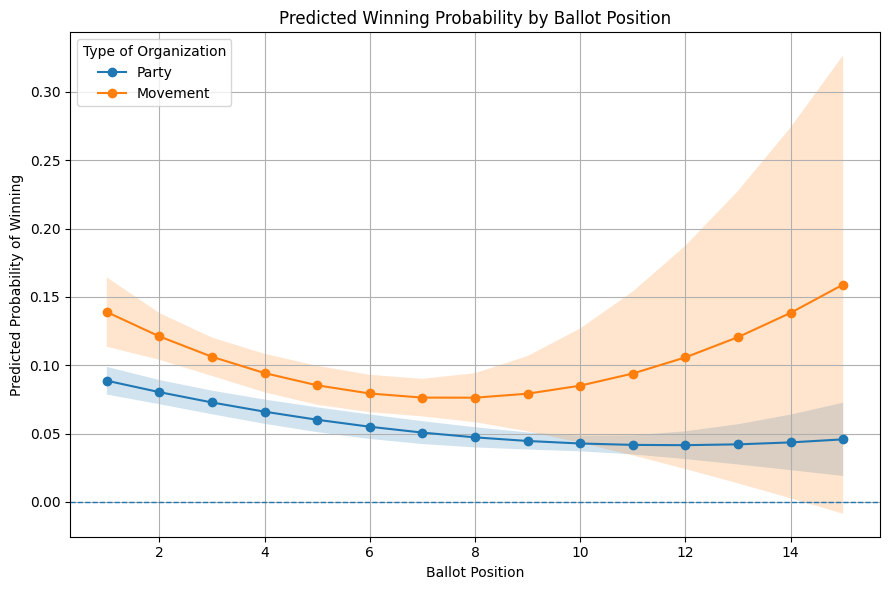

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. MODEL 
# =========================================================
model_nonlinear = m3_3

# =========================================================
# 2. CREATE A GRID OF POSITIONS AND ORGANIZATION TYPES
# =========================================================

pos_grid = pd.DataFrame({
    "position": np.tile(np.arange(1, 16), 2),
    "movement": np.repeat([0, 1], 15)
})

pos_grid["position_sq"] = pos_grid["position"] ** 2

# =========================================================
# 3. SET FIXED EFFECTS TO A REFERENCE CATEGORY
# =========================================================
# Since the model includes district and year fixed effects,
# predictions need values for those variables.
# We set them to one observed district and one observed year.
# This affects the level, but not the shape of the relationship.

ref_ubigeo = df["ubigeo"].mode().iloc[0]
ref_year = df["year"].mode().iloc[0]

pos_grid["ubigeo"] = ref_ubigeo
pos_grid["year"] = ref_year

# =========================================================
# 4. GENERATE PREDICTIONS
# =========================================================

pred = model_nonlinear.get_prediction(pos_grid).summary_frame(alpha=0.05)

pos_grid["predicted_win"] = pred["mean"]
pos_grid["ci_low"] = pred["mean_ci_lower"]
pos_grid["ci_high"] = pred["mean_ci_upper"]

pos_grid["org_type"] = np.where(pos_grid["movement"] == 1, "Movement", "Party")

print(pos_grid.head(10))

# =========================================================
# 5. PLOT PREDICTED WINNING PROBABILITY
# =========================================================

plt.figure(figsize=(9, 6))

for org in ["Party", "Movement"]:
    temp = pos_grid[pos_grid["org_type"] == org].copy()

    plt.plot(
        temp["position"],
        temp["predicted_win"],
        marker="o",
        label=org
    )

    plt.fill_between(
        temp["position"],
        temp["ci_low"],
        temp["ci_high"],
        alpha=0.2
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Ballot Position")
plt.ylabel("Predicted Probability of Winning")
plt.title("Predicted Winning Probability by Ballot Position")
plt.legend(title="Type of Organization")
plt.grid(True)
plt.tight_layout()

plt.savefig("marginal_effects_position.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# =========================================================
# LATEX TABLES FOR OVERLEAF
# =========================================================

column_labels = ["(1)", "(2)", "(3)", "(4)"]

# --------------------------------
# TABLE 1
# --------------------------------
row_order_t1 = ["position", "movement"]
row_labels_t1 = {
    "position": "Position",
    "movement": "Regional movement"
}
fe_rows_t1 = {
    "District FE": ["No", "Yes", "Yes", "Yes"],
    "Election year FE": ["No", "No", "Yes", "Yes"],
    "Regional movement control": ["No", "No", "No", "Yes"]
}

latex_t1 = write_latex_table(
    models=models_table1,
    column_labels=column_labels,
    row_order=row_order_t1,
    row_labels=row_labels_t1,
    fe_rows=fe_rows_t1,
    depvar_mean=depvar_mean,
    n_obs=n_obs,
    n_clusters=n_clusters,
    caption="List Position and Probability of Winning: Baseline Specifications",
    label="tab:baseline_specs",
    file_path=output_dir / "table1_baseline.tex"
)

# --------------------------------
# TABLE 2
# --------------------------------
row_order_t2 = ["position", "movement", "position:movement"]
row_labels_t2 = {
    "position": "Position",
    "movement": "Regional movement",
    "position:movement": "Position $\\times$ Regional movement"
}
fe_rows_t2 = {
    "District FE": ["No", "Yes", "Yes"],
    "Election year FE": ["No", "No", "Yes"],
    "Regional movement control": ["Yes", "Yes", "Yes"]
}

latex_t2 = write_latex_table(
    models=models_table2,
    column_labels=column_labels,
    row_order=row_order_t2,
    row_labels=row_labels_t2,
    fe_rows=fe_rows_t2,
    depvar_mean=depvar_mean,
    n_obs=n_obs,
    n_clusters=n_clusters,
    caption="List Position and Probability of Winning: Interaction with Regional Movement",
    label="tab:interaction_specs",
    file_path=output_dir / "table2_interaction.tex"
)

# --------------------------------
# TABLE 3
# --------------------------------
row_order_t3 = ["position", "position_sq", "movement", "position:movement", "position_sq:movement"]
row_labels_t3 = {
    "position": "Position",
    "position_sq": "Position squared",
    "movement": "Regional movement",
    "position:movement": "Position $\\times$ Regional movement",
    "position_sq:movement": "Position squared $\\times$ Regional movement"
}
fe_rows_t3 = {
    "District FE": ["No", "Yes", "Yes"],
    "Election year FE": ["No", "No", "Yes"],
    "Regional movement control": ["Yes", "Yes", "Yes"]
}

latex_t3 = write_latex_table(
    models=models_table3,
    column_labels=column_labels,
    row_order=row_order_t3,
    row_labels=row_labels_t3,
    fe_rows=fe_rows_t3,
    depvar_mean=depvar_mean,
    n_obs=n_obs,
    n_clusters=n_clusters,
    caption="List Position and Probability of Winning: Nonlinear Interaction with Regional Movement",
    label="tab:nonlinear_interaction_specs",
    file_path=output_dir / "table3_nonlinear.tex"
)

# =========================================================
# 12. SAVE CSV OF MAIN COEFFICIENTS (OPTIONAL)
# =========================================================

def collect_model_results(models, model_names):
    rows = []
    for model_name, model in zip(model_names, models):
        for var in model.params.index:
            rows.append({
                "model": model_name,
                "variable": var,
                "coef": model.params[var],
                "se": model.bse[var],
                "pvalue": model.pvalues[var],
                "nobs": int(model.nobs),
                "r2": model.rsquared
            })
    return pd.DataFrame(rows)

results_t1 = collect_model_results(models_table1, ["m1", "m2", "m3", "m4"])
results_t2 = collect_model_results(models_table2, ["m1", "m2", "m3"])
results_t3 = collect_model_results(models_table3, ["m1", "m2", "m3"])

results_t1.to_csv(output_dir / "results_table1.csv", index=False)
results_t2.to_csv(output_dir / "results_table2.csv", index=False)
results_t3.to_csv(output_dir / "results_table3.csv", index=False)

# =========================================================
# 13. SAVE FINAL ANALYSIS DATA
# =========================================================

df.to_csv(output_dir / "analysis_dataset_final.csv", index=False)

# =========================================================
# 14. PRINT LATEX TO SCREEN
# =========================================================

print("\n" + "=" * 80)
print("TABLE 1 LATEX")
print("=" * 80)
print(latex_t1)

print("\n" + "=" * 80)
print("TABLE 2 LATEX")
print("=" * 80)
print(latex_t2)

print("\n" + "=" * 80)
print("TABLE 3 LATEX")
print("=" * 80)
print(latex_t3)

print("\nFiles saved:")
print("- table1_baseline.tex")
print("- table2_interaction.tex")
print("- table3_nonlinear.tex")
print("- results_table1.csv")
print("- results_table2.csv")
print("- results_table3.csv")
print("- analysis_dataset_final.csv")


TABLE 1 LATEX
\begin{table}[htbp]
\centering
\caption{List Position and Probability of Winning: Baseline Specifications}
\label{tab:baseline_specs}
\begin{tabular}{lcccc}
\toprule
 & (1) & (2) & (3) & (4) \\
\midrule
Position & -0.0138*** (0.0006) & -0.0072*** (0.0007) & -0.0063*** (0.0007) & -0.0057*** (0.0007) \\
Regional movement &  &  &  & 0.0341*** (0.0055) \\
\midrule
District FE & No & Yes & Yes & Yes \\
Election year FE & No & No & Yes & Yes \\
Regional movement control & No & No & No & Yes \\
Mean dep. var. & 0.1667 & 0.1667 & 0.1667 & 0.1667 \\
Observations & 51862 & 51862 & 51862 & 51862 \\
Clusters & 1693 & 1693 & 1693 & 1693 \\
\bottomrule
\end{tabular}
\begin{flushleft}
\footnotesize Robust standard errors clustered at the district level in parentheses. * $p<0.10$, ** $p<0.05$, *** $p<0.01$.
\end{flushleft}
\end{table}

TABLE 2 LATEX
\begin{table}[htbp]
\centering
\caption{List Position and Probability of Winning: Interaction with Regional Movement}
\label{tab:interactio